In [1]:
from quickdraw import QuickDrawDataGroup
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [2]:
with open('../../categories/sports.txt') as f:
    CATEGORIES = [c.strip() for c in f.read().split(',')]
print(CATEGORIES)

['baseball', 'baseball bat', 'basketball', 'bicycle', 'canoe', 'dumbbell', 'diving board', 'golf club', 'hockey puck', 'hockey stick', 'rollerskates', 'skateboard', 'soccer ball', 'tennis racquet', 'yoga']


In [3]:
SAMPLES = 500
IMG_SIZE = 16
images = []
labels = []
for cat in CATEGORIES:
    group = QuickDrawDataGroup(cat, max_drawings=SAMPLES)
    for drawing in group.drawings:
        img = np.array(drawing.image.convert('L').resize((IMG_SIZE, IMG_SIZE)))
        images.append(img)
        labels.append(cat)

loading baseball drawings
load complete
loading baseball bat drawings
load complete
loading basketball drawings
load complete
loading bicycle drawings
load complete
loading canoe drawings
load complete
loading dumbbell drawings
load complete
loading diving board drawings
load complete
loading golf club drawings
load complete
loading hockey puck drawings
load complete
loading hockey stick drawings
load complete
loading rollerskates drawings
load complete
loading skateboard drawings
load complete
loading soccer ball drawings
load complete
loading tennis racquet drawings
load complete
loading yoga drawings
load complete


In [4]:
label_map = {cat: i for i, cat in enumerate(CATEGORIES)}

X = np.array(images) / 255.0 
y = np.array([label_map[l] for l in labels])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")


Train: (6000, 16, 16), Test: (1500, 16, 16)


In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

X_train_t = torch.tensor(X_train, dtype=torch.float32).unsqueeze(1)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_test_t = torch.tensor(X_test, dtype=torch.float32).unsqueeze(1)
y_test_t = torch.tensor(y_test, dtype=torch.long)

num_classes = len(CATEGORIES)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=32, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=32, shuffle=False)


class SimpleCNN(nn.Module):
    def __init__(self, num_classes=len(CATEGORIES), img_size=IMG_SIZE):
        super().__init__()

        # Layer 1: conv -> relu -> pool   (1 channel -> 16 channels, spatial size halved)
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1)
        # Layer 2: conv -> relu -> pool   (16 channels -> 32 channels, spatial size halved again)
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # after 2 pools, spatial size is img_size / 4
        final_size = img_size // 4
        self.fc = nn.Linear(32 * final_size * final_size, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))   # (B, 16, size/2, size/2)
        x = self.pool(F.relu(self.conv2(x)))   # (B, 32, size/4, size/4)
        x = x.flatten(1)                        # flatten everything except batch dim
        return self.fc(x)


In [6]:
model = SimpleCNN(num_classes=num_classes, img_size=IMG_SIZE)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss() 

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

SimpleCNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc): Linear(in_features=512, out_features=15, bias=True)
)

In [7]:
num_epochs = 15

for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * xb.size(0)

    train_loss = total_loss / len(train_loader.dataset)

    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for x_eval, y_eval in test_loader:
            x_eval, y_eval = x_eval.to(device), y_eval.to(device)
            preds = model(x_eval).argmax(dim=1)
            correct += (preds == y_eval).sum().item()
            total += y_eval.size(0)

    test_acc = correct / total
    print(f"Epoch: {epoch+1} | loss: {train_loss:.4f} | acc: {test_acc:.4f}")


Epoch: 1 | loss: 2.7106 | acc: 0.1213
Epoch: 2 | loss: 2.6935 | acc: 0.2193
Epoch: 3 | loss: 2.4330 | acc: 0.3213
Epoch: 4 | loss: 2.0224 | acc: 0.3933
Epoch: 5 | loss: 1.8561 | acc: 0.4293
Epoch: 6 | loss: 1.8208 | acc: 0.4553
Epoch: 7 | loss: 1.7729 | acc: 0.4827
Epoch: 8 | loss: 1.7348 | acc: 0.4787
Epoch: 9 | loss: 1.7045 | acc: 0.4687
Epoch: 10 | loss: 1.6738 | acc: 0.4767
Epoch: 11 | loss: 1.6446 | acc: 0.5180
Epoch: 12 | loss: 1.6342 | acc: 0.5147
Epoch: 13 | loss: 1.5946 | acc: 0.5120
Epoch: 14 | loss: 1.5602 | acc: 0.5060
Epoch: 15 | loss: 1.5368 | acc: 0.5280


                precision    recall  f1-score   support

      baseball       0.65      0.45      0.53       100
  baseball bat       0.53      0.52      0.52       100
    basketball       0.41      0.75      0.53       100
       bicycle       0.49      0.75      0.59       100
         canoe       0.50      0.58      0.53       100
      dumbbell       0.59      0.42      0.49       100
  diving board       0.64      0.32      0.43       100
     golf club       0.44      0.52      0.48       100
   hockey puck       0.64      0.47      0.54       100
  hockey stick       0.58      0.37      0.45       100
  rollerskates       0.69      0.72      0.70       100
    skateboard       0.43      0.66      0.52       100
   soccer ball       0.71      0.32      0.44       100
tennis racquet       0.59      0.60      0.60       100
          yoga       0.48      0.47      0.47       100

      accuracy                           0.53      1500
     macro avg       0.56      0.53      0.52 

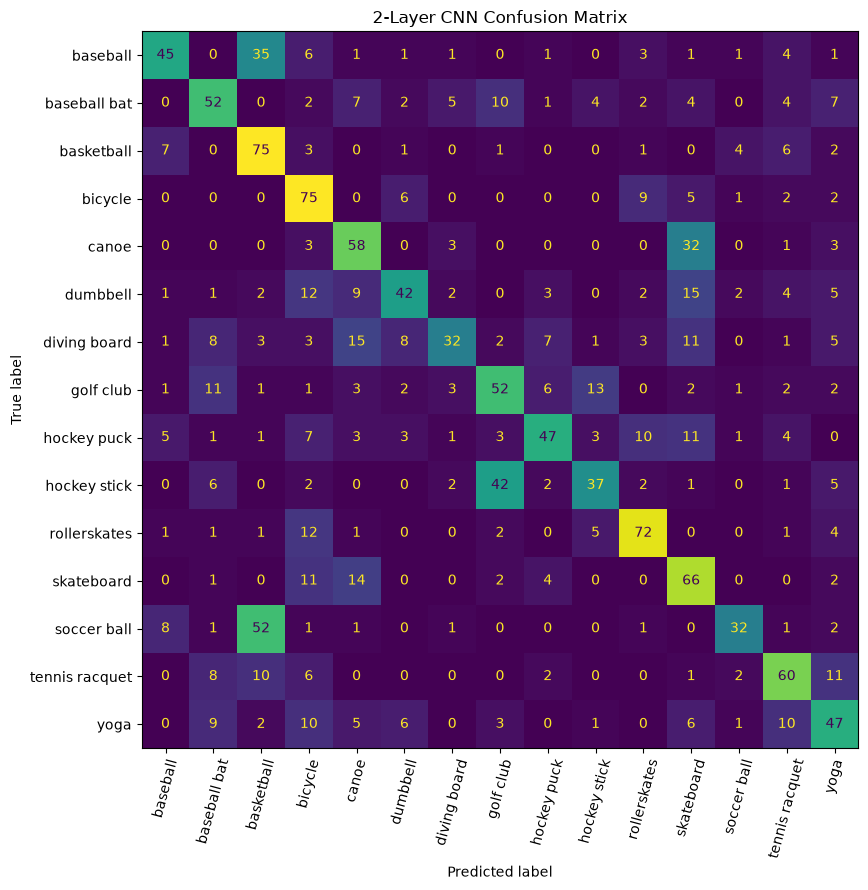

In [8]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for x_eval, y_eval in test_loader:
        x_eval, y_eval = x_eval.to(device), y_eval.to(device)
        batch_preds = model(x_eval).argmax(dim=1)
        all_preds.append(batch_preds.cpu())
        all_labels.append(y_eval.cpu())

preds = torch.cat(all_preds).numpy()
y_test_final = torch.cat(all_labels).numpy()

print(classification_report(y_test_final, preds, target_names=CATEGORIES, zero_division=0))

fig, ax = plt.subplots(figsize=(10, 9))
ConfusionMatrixDisplay.from_predictions(
    y_test_final, preds, display_labels=CATEGORIES, xticks_rotation=75, ax=ax, colorbar=False
)
plt.title("2-Layer CNN Confusion Matrix")
plt.tight_layout()
plt.show()
